<a href="https://www.kaggle.com/code/samirmidris/sudan-food-security-prices-2010-2026-notebook?scriptVersionId=302836193" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<p align="center">
  <img src="https://storage.googleapis.com/kaggle-datasets-images/9535649/14902876/3909a34172c6e163ee4e91c8dd4c6943/dataset-cover.jpeg?t=2026-02-20-20-01-29" width="800">
</p>

# 🌾 Analysis of Food Price Volatility in Sudan (2010 - 2026)
<p><i>A Data Journey through Sudan’s Food Markets (2010 - 2026)</i>
</p>

---

## 👤 Author Info:
**Samir M. Idris**<br>
**Sr. Software Engineer (AI/ML), MSc.IT, PhD Applicant**<br>
smohamedidris@acm.org | samir.idris@hotmail.com |
[LinkedIn](https://www.linkedin.com/in/samiridris/) |
[Kaggle](https://www.kaggle.com/samirmidris) |
[GitHub](https://github.com/samir-m-idris)

---

## 🧑 A Personal Note
As a resident observing economic changes in Sudan, these numbers aren't just data points on a spreadsheet—they represent the reality of our daily lives. I've seen these price changes firsthand at local markets, where the cost of staple grains can shift significantly in just a few weeks. This notebook explores the economic data behind the bread and meals we eat every day.

## 📌 Objectives
In this notebook, I will investigate:

- **The Staple Spike:** How have prices for key grains like Wheat and Sorghum changed during recent years?
- **Market Disruption:** Identifying which states (like Khartoum or North Darfur) show the highest price volatility.
- **Economic Resilience:** Visualizing the long-term trends from 2010 to 2026 to understand the scale of current inflation.

These analyses aim to transform raw price data into actionable insights about market behavior and economic stability.

## 🛠️ Data Source
The data is sourced from the **World Food Programme (WFP)** via the **Humanitarian Data Exchange (HDX)**. It covers over 15 years of monthly price records across 18 Sudanese states.

## Table of Contents
1. [Data Loading & Cleaning](#cleaning)
2. [Exploratory Data Analysis (EDA)](#eda)
3. [The Wheat Price Index](#wheat)
4. [State-wise Comparison](#states)
5. [Conclusion: Insights & Findings](#conclusion)

## 1️⃣ Data Loading and Cleaning

In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

# Load the dataset
df = pd.read_csv('/kaggle/input/sudan-food-security-market-prices-2010-2026/wfp_food_prices_sdn.csv')

# Quick Preview
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2001-01-15,Blue Nile,Damazin,Damazin,1026,11.79,34.36,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,46.00,17.76
1,2001-01-15,Gedaref,Al Gedaref Rural,El Gedarif,2580,14.04,35.38,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,51.67,19.95
2,2001-01-15,Khartoum,Jebal Aulya,Khartoum,2588,15.51,32.54,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,63.90,24.67
3,2001-01-15,North Kordofan,Shiekan,El Obeid,1029,13.19,30.22,cereals and tubers,Millet,73,90 KG,actual,Wholesale,SDG,66.25,25.58
4,2001-02-15,Khartoum,Jebal Aulya,Khartoum,2588,15.51,32.54,cereals and tubers,Wheat,84,90 KG,actual,Wholesale,SDG,82.36,31.80


In [2]:
# Basic Info (Columns + Types + Missing)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14638 entries, 0 to 14637
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          14638 non-null  object 
 1   admin1        14638 non-null  object 
 2   admin2        14638 non-null  object 
 3   market        14638 non-null  object 
 4   market_id     14638 non-null  int64  
 5   latitude      14638 non-null  float64
 6   longitude     14638 non-null  float64
 7   category      14638 non-null  object 
 8   commodity     14638 non-null  object 
 9   commodity_id  14638 non-null  int64  
 10  unit          14638 non-null  object 
 11  priceflag     14638 non-null  object 
 12  pricetype     14638 non-null  object 
 13  currency      14638 non-null  object 
 14  price         14638 non-null  float64
 15  usdprice      14638 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 1.8+ MB


In [3]:
# Rows & Columns Count
df.shape

(14638, 16)

In [4]:
# Columns names
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [5]:
# Rows Count Only
len(df)

14638

In [6]:
# Missing Values Summary
df.isnull().sum()

date            0
admin1          0
admin2          0
market          0
market_id       0
latitude        0
longitude       0
category        0
commodity       0
commodity_id    0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64

In [7]:
null_counts = df.isnull().sum()

if null_counts.sum() > 0:
    print("Missing values detected:")
    print(null_counts[null_counts > 0])
else:
    print("No missing values found. Clean Dataset!")

No missing values found. Clean Dataset!


In [8]:
# If null values exist, we have 3 options to choose from. Not in this case!
'''
# Option 1 – Drop
df = df.dropna()

# Option 2 – Fill with value
df['column'] = df['column'].fillna(0)

# Option 3 – Fill with mean (numeric)
df['column'] = df['column'].fillna(df['column'].mean())
'''

"\n# Option 1 – Drop\ndf = df.dropna()\n\n# Option 2 – Fill with value\ndf['column'] = df['column'].fillna(0)\n\n# Option 3 – Fill with mean (numeric)\ndf['column'] = df['column'].fillna(df['column'].mean())\n"

In [9]:
# Quick Statistics for Numeric Columns
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000
mean,1538.442000,13.758815,30.104069,204.328870,2587.773486,14.618249
std,1392.020193,2.480873,4.618811,244.442176,8270.430101,26.046073
min,1025.000000,11.020000,22.450000,58.000000,0.660000,0.130000
25%,1028.000000,11.790000,25.350000,73.000000,38.092500,1.590000
50%,1031.000000,13.190000,30.220000,97.000000,348.375000,3.540000
75%,1034.000000,14.400000,34.360000,238.000000,2200.000000,14.190000
max,9031.000000,19.620000,37.220000,1178.000000,370833.000000,617.880000


In [10]:
# 2. Convert date
df['date'] = pd.to_datetime(df['date'])

## 2️⃣ Exploratory Data Analysis (EDA)

In [33]:
# 3. Find the exact Wheat name (Safety Check)
# This looks for any commodity containing the word 'Wheat'
wheat_options = [c for c in df['commodity'].unique() if 'Wheat' in str(c)]
print(f"Found these Wheat types: {wheat_options}")

if wheat_options:
    target_wheat = wheat_options[0] # Picks the first one found (usually 'Wheat flour')
    wheat_df = df[df['commodity'] == target_wheat].copy()

    # 4. Group & Smooth
    wheat_trend = wheat_df.groupby('date')['price'].mean().reset_index()
    wheat_trend['smooth_price'] = wheat_trend['price'].rolling(window=3).mean()

    # 5. Create Chart
    fig = px.line(wheat_trend, x='date', y='smooth_price',
                  title=f'Sudan Food Crisis: {target_wheat} Price Trend',
                  labels={'smooth_price': 'Price (SDG)', 'date': 'Year'},
                  template='plotly_dark')

    # Force display for Kaggle
    fig.show()


    from IPython.display import Markdown, display

    display(Markdown("""
    ### Interpretation

    The chart shows the price trend over time.
    Sharp spikes indicate periods of market instability,
    while the rolling average smooths short-term fluctuations.

    Prices remained relatively stable before 2019, indicating market equilibrium.
    However, a sharp upward trend appears after 2019, likely reflecting macroeconomic instability,
    currency depreciation, and external shocks affecting food supply and import costs.
    """))
else:
    print("Error: Could not find any commodity with 'Wheat' in the name.")
    print("Available commodities are:", df['commodity'].unique()[:10])

Found these Wheat types: ['Wheat', 'Wheat flour']



    ### Interpretation

    The chart shows the price trend over time.
    Sharp spikes indicate periods of market instability,
    while the rolling average smooths short-term fluctuations.

    Prices remained relatively stable before 2019, indicating market equilibrium.
    However, a sharp upward trend appears after 2019, likely reflecting macroeconomic instability,
    currency depreciation, and external shocks affecting food supply and import costs.
    

In [12]:
print(df['commodity'].unique())

['Sorghum (white)' 'Millet' 'Wheat' 'Sorghum' 'Sorghum (food aid)'
 'Exchange rate (unofficial)' 'Meat (goat)' 'Milk (powder)' 'Sugar'
 'Oil (vegetable)' 'Onions' 'Tomatoes (dried)' 'Meat (beef)'
 'Salt (iodised)' 'Beans (fava, egyptian)' 'Wheat flour']


In [13]:
# Correlation (If Numeric Data)
df.corr(numeric_only=True)

,market_id,latitude,longitude,commodity_id,price,usdprice
market_id,1.000000,0.210947,0.184736,0.058715,0.106298,0.057027
latitude,0.210947,1.000000,0.507663,-0.009164,0.029375,0.121097
longitude,0.184736,0.507663,1.000000,-0.018908,0.021727,0.079351
commodity_id,0.058715,-0.009164,-0.018908,1.000000,0.075113,-0.115806
price,0.106298,0.029375,0.021727,0.075113,1.000000,0.469493
usdprice,0.057027,0.121097,0.079351,-0.115806,0.469493,1.000000


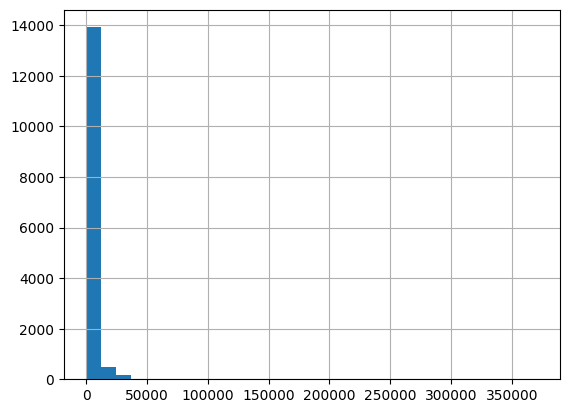

In [14]:
# Distribution Example (For One Key Column)
import matplotlib.pyplot as plt

df['price'].hist(bins=30)
plt.show()

<Axes: xlabel='price'>

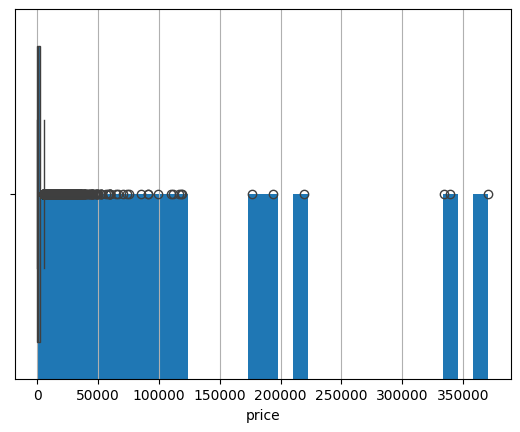

In [15]:
# Boxplot (Detect Outliers)

import seaborn as sns

df['price'].hist(bins=30)
sns.boxplot(x=df['price'])

<Axes: xlabel='commodity', ylabel='price'>

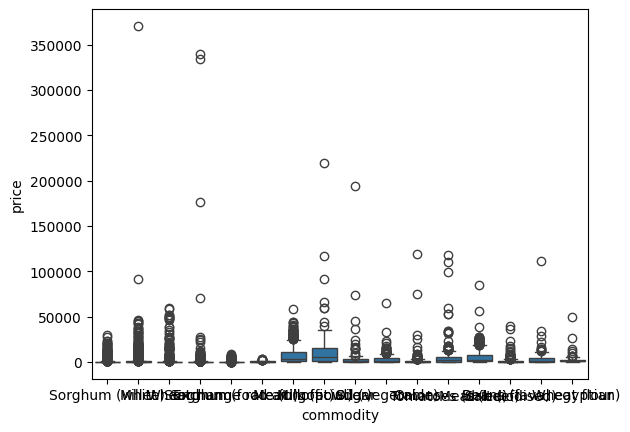

In [16]:
# Price by Commodity
sns.boxplot(x='commodity', y='price', data=df)

<Axes: xlabel='date'>

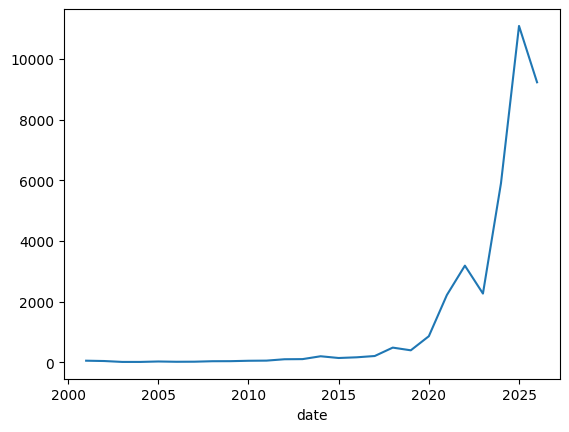

In [17]:
# Monthly / Yearly Average Trend

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'].dtype

#Group by year:
df.groupby(df['date'].dt.year)['price'].mean().plot()

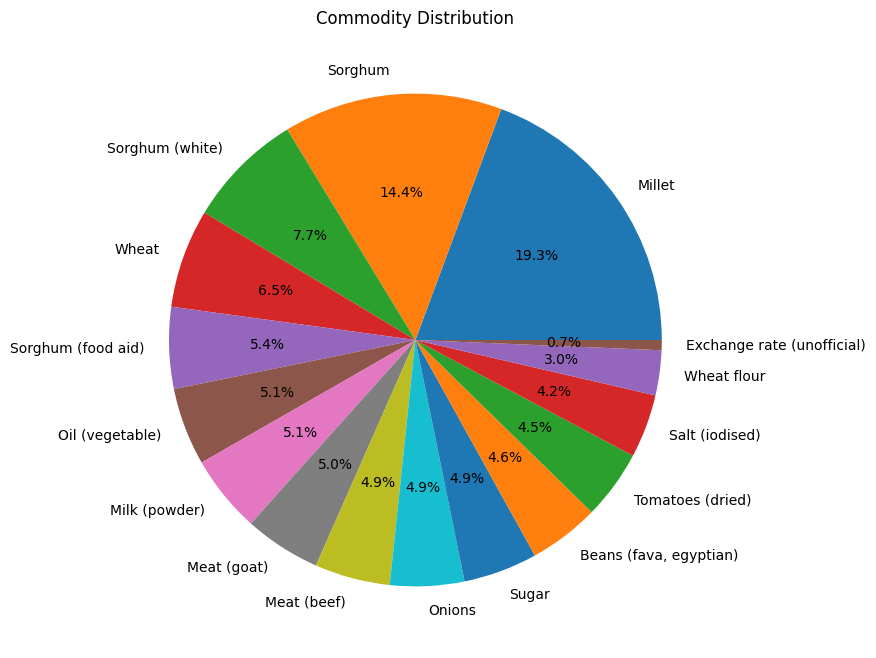

In [18]:
# Pie chart for commodity counts

import matplotlib.pyplot as plt

counts = df['commodity'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Commodity Distribution")
plt.show()

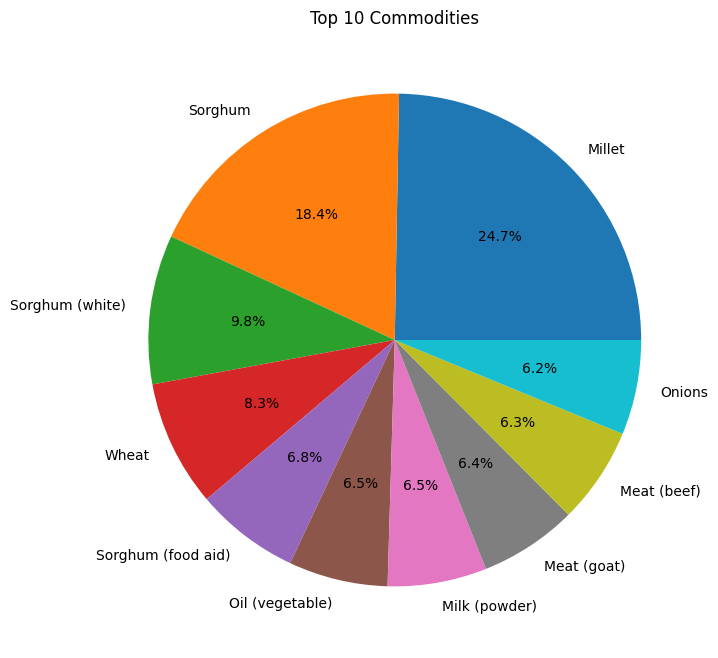

In [19]:
# Pie chart for Top#10 Commodities

counts = df['commodity'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Top 10 Commodities")
plt.show()

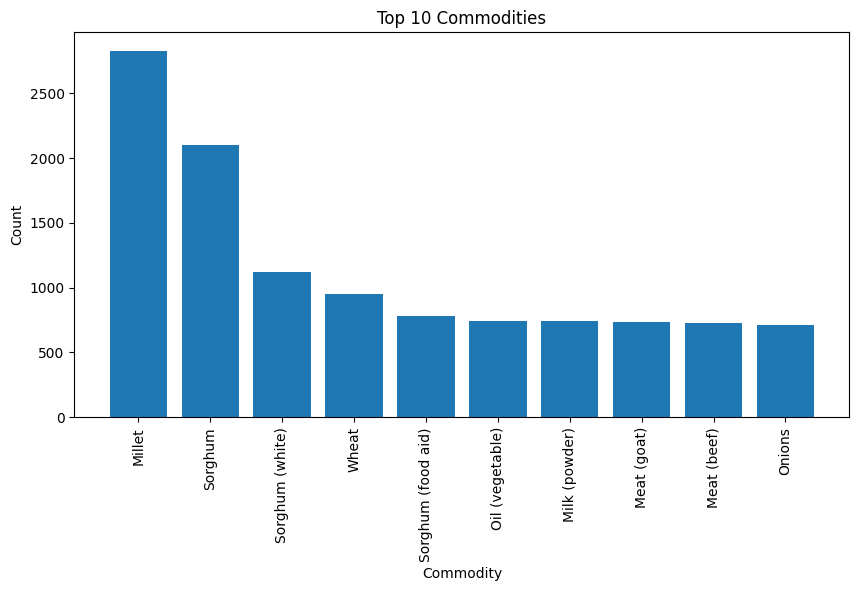

In [20]:
# Bar Chart (Matplotlib) - Top 10 Commodities by Frequency
counts = df['commodity'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.xlabel("Commodity")
plt.ylabel("Count")
plt.title("Top 10 Commodities")
plt.show()

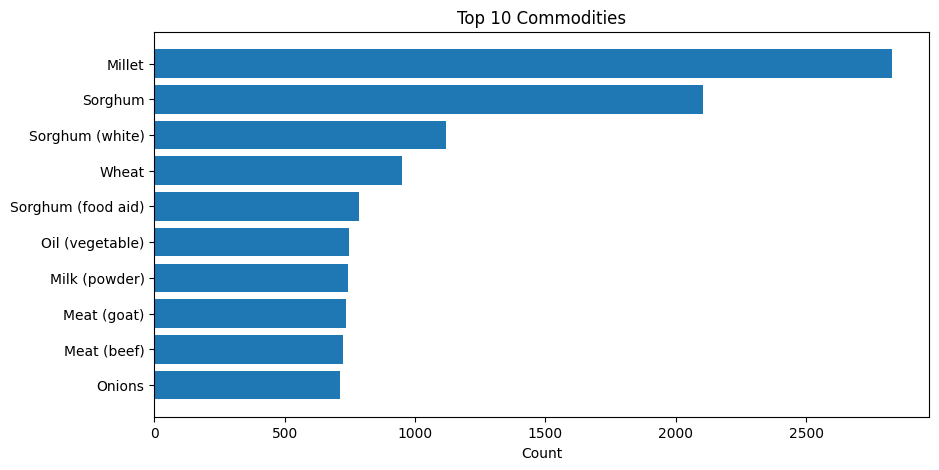

In [21]:
# Same Chart, but Horizontal
counts = df['commodity'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(counts.index[::-1], counts.values[::-1])  # Horizontal bar
plt.xlabel("Count")
plt.title("Top 10 Commodities")
plt.show()

## 3️⃣ The Wheat Price Index
This section analyzes wheat price dynamics over time to understand its trend, volatility, and structural shifts within the market.

In [22]:
wheat_df = df[df['commodity'].str.contains("Wheat", case=False, na=False)].copy()
wheat_df['price'].describe()

count     1381.000000
mean      1756.374909
std       5850.087273
min          0.830000
25%          5.000000
50%        200.000000
75%       1200.000000
max      60000.000000
Name: price, dtype: float64

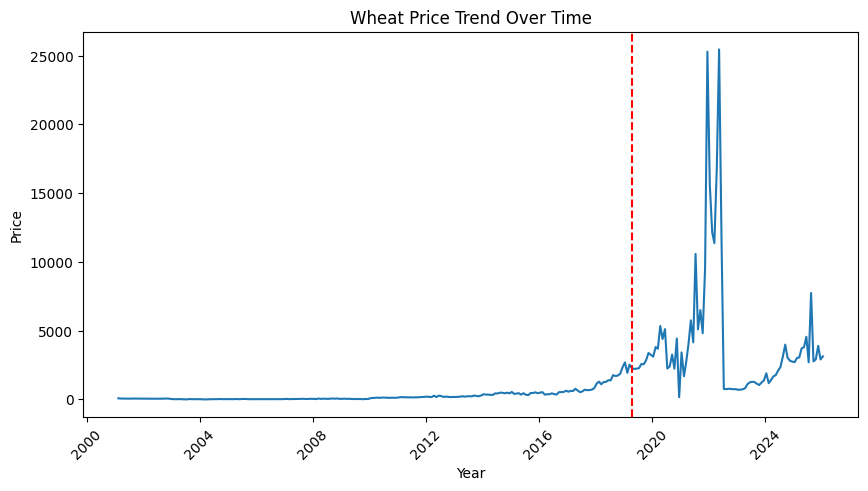


### Interpretation
The chart illustrates the temporal evolution of wheat prices over time. A noticeable upward trend and increased volatility appear after 2019, indicating significant market instability. The sharp price fluctuations suggest external economic pressures, supply chain disruptions, and macroeconomic changes affecting wheat pricing dynamics.


In [23]:
# Plot Wheat Price Trend
wheat_trend = wheat_df.groupby('date')['price'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(wheat_trend['date'], wheat_trend['price'])
plt.title("Wheat Price Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.axvline(pd.Timestamp("2019-04-11"), color='red', linestyle='--')
plt.show()

display(Markdown("""
### Interpretation
The chart illustrates the temporal evolution of wheat prices over time. A noticeable upward trend and increased volatility appear after 2019, indicating significant market instability. The sharp price fluctuations suggest external economic pressures, supply chain disruptions, and macroeconomic changes affecting wheat pricing dynamics.
"""))

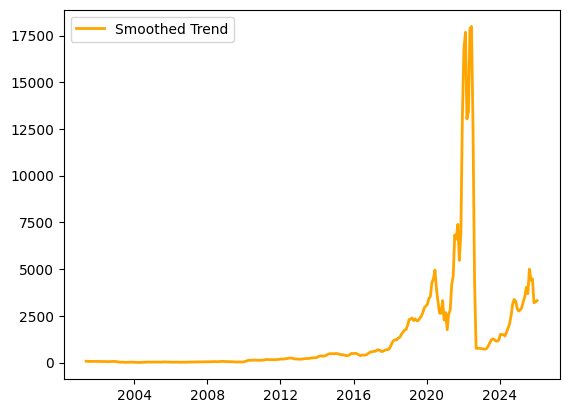

In [24]:
# Rolling Average (Makes the trend smoother)
wheat_trend['smooth'] = wheat_trend['price'].rolling(window=3).mean()

plt.plot(wheat_trend['date'], wheat_trend['smooth'],
         color='orange', linewidth=2, label="Smoothed Trend")
plt.legend()

## 4️⃣ State-wise Comparison

In [25]:
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [26]:
# Average Price Per State
# admin1 = State
state_avg = df.groupby('admin1')['price'].mean().sort_values()
state_avg

admin1
West Darfur       1377.125264
Eastern Darfur    1477.364775
South Darfur      1786.444941
North Kordofan    1893.564421
Central Darfur    2051.583281
Kassala           2082.749475
White Nile        2097.588931
Red Sea           2199.522152
Blue Nile         2261.939326
Khartoum          2412.614874
West Kordofan     2474.059060
South Kordofan    2848.057121
Gedaref           3655.609619
Northern          4184.209486
North Darfur      4197.535351
Nile              6871.025126
Sennar            7022.500983
Al Gezira         7413.550987
Name: price, dtype: float64

In [27]:
#Top 5 States
state_avg.head(5)

admin1
West Darfur       1377.125264
Eastern Darfur    1477.364775
South Darfur      1786.444941
North Kordofan    1893.564421
Central Darfur    2051.583281
Name: price, dtype: float64

In [28]:
# Bottom 5 States
state_avg.tail(5)

admin1
Northern        4184.209486
North Darfur    4197.535351
Nile            6871.025126
Sennar          7022.500983
Al Gezira       7413.550987
Name: price, dtype: float64

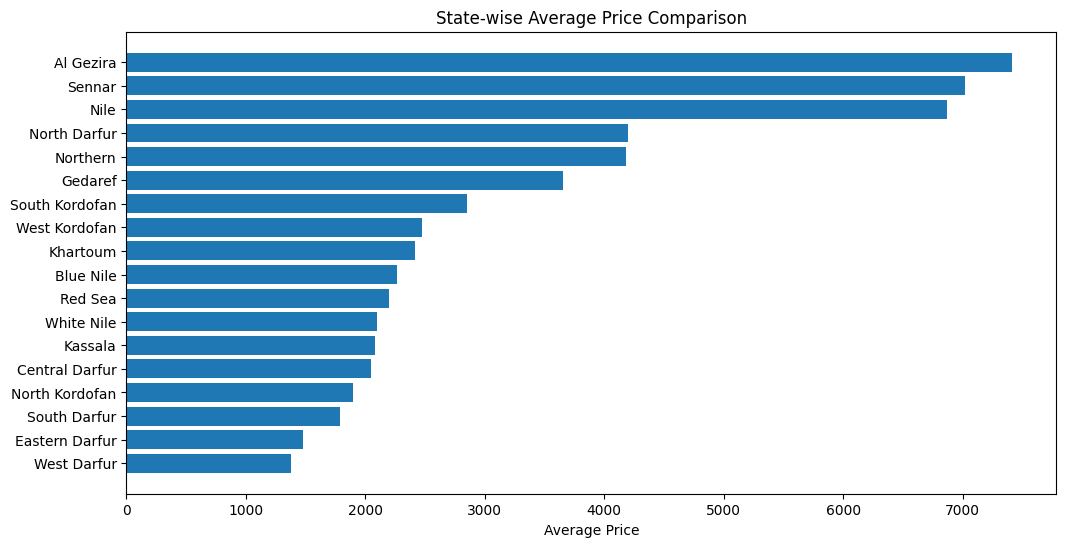


### Interpretation
The chart presents the average price of commodities across different states (admin1 regions). Significant price variation between states indicates regional disparities in market conditions, supply accessibility, transportation costs, and economic stability.


In [29]:
# Bar Chart (State Comparison)
plt.figure(figsize=(12,6))
plt.barh(state_avg.index, state_avg.values)

plt.xlabel("Average Price")
plt.title("State-wise Average Price Comparison")
plt.show()

display(Markdown("""
### Interpretation
The chart presents the average price of commodities across different states (admin1 regions). Significant price variation between states indicates regional disparities in market conditions, supply accessibility, transportation costs, and economic stability.
"""))

In [30]:
state_avg.head(5)
state_avg.tail(5)

admin1
Northern        4184.209486
North Darfur    4197.535351
Nile            6871.025126
Sennar          7022.500983
Al Gezira       7413.550987
Name: price, dtype: float64

In [31]:
# Time Series Analysis
import plotly.express as px

fig = px.line(df, x='date', y='price', color='market', 
              title='Trend of Food Prices in Sudan Markets')
fig.show()

from IPython.display import Markdown, display

display(Markdown("""
📈 **Time Series Analysis: Food Price Dynamics:**<br>
In this section, I perform a Time Series Analysis to visualize the fluctuations in food prices across various Sudanese markets. By utilizing the Plotly library, we can observe the price trends and identify specific periods of volatility.    
"""))


📈 **Time Series Analysis: Food Price Dynamics:**<br>
In this section, I perform a Time Series Analysis to visualize the fluctuations in food prices across various Sudanese markets. By utilizing the Plotly library, we can observe the price trends and identify specific periods of volatility.    


## 5️⃣ Conclusion: Insights & Findings
The analysis reveals a clear structural shift in food prices after 2019, marked by increased volatility and sustained upward trends. Regional disparities indicate unequal market conditions across states, suggesting differences in supply access, transportation infrastructure, and economic stability. Overall, the data highlights growing market instability in recent years.

The post-2019 price surge coincides with major global, regional, and local events, including the COVID-19 pandemic, political transition in Sudan, economic instability with hyperinflation, and the ongoing armed conflict between the Sudanese Armed Forces (SAF) and Rapid Support Forces (RSF). These factors may have contributed to supply chain disruptions and increased inflationary pressure.

### Recommendations

- Improve market supply chain efficiency
- Strengthen regional price monitoring
- Investigate drivers of post-2019 price increases

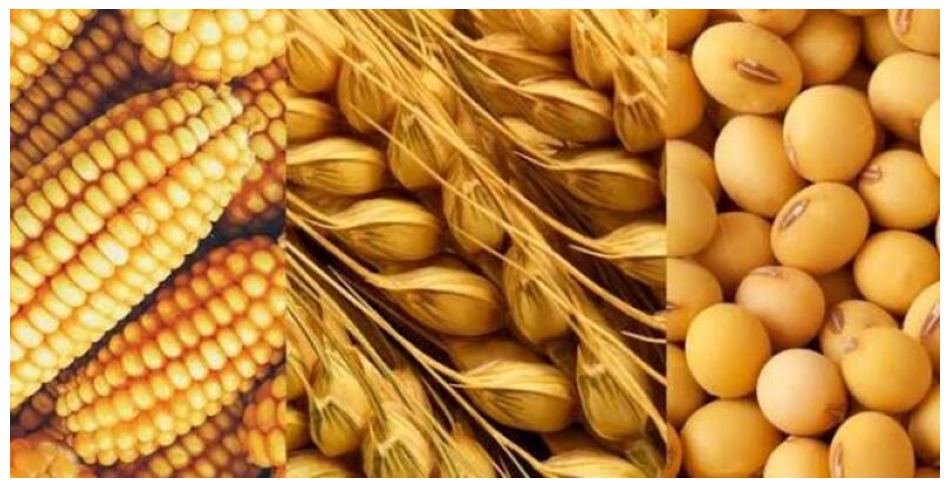

In [32]:
'''
IGNORE THE FOLLOWING CODE!
JUST TESTING SOMETHING OUT OF CONTEXT HERE!
'''

import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 1. Your Image URL (Replace this with your chosen image link)
url = "https://storage.googleapis.com/kaggle-datasets-images/9535649/14902876/3909a34172c6e163ee4e91c8dd4c6943/dataset-cover.jpeg?t=2026-02-20-20-01-29"

# 2. Grab the image from the web
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# 3. Plot it so Kaggle uses it as the thumbnail
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.axis('off')  # Keeps it clean without numbers on the side
plt.show()